In [1]:
# Parameters
sensible_attribute = "age-sex"


### Variables Overview
Y = **income** (target variable column)

X = **input features** to train the model -- dataset without target column

Data split: Training 70%, Validation 15%, Testing 15%

**Pipeline:**
1. Model 1: Fit on training → Predict on validation → Compute fairness metrics, penalty, **weights**
2. Model 1: Fit on training → Predict on test → Compute fairness metrics, penalty **FOR COMPARISON PURPOSES**
2. Model 2: Fit on training (with weights) → Predict on test → Compute fairness metrics, **penalty FOR COMPARISON PURPOSES**

### Utils Overview

Confusion matrix computed to obtain TP, FP, TN, FN 

Performance metrics computed (fairness_metrics_utils): Precision, Recall, Accuracy, F1

In [2]:
import sys
sys.path.append('../../utils')

from fairness_metric_utils import *
from penalty_utils import *
from weight_utils import *

# Load Data

In [3]:
dataset_path = '../../../COMPAS/compas-preprocessed-binary.csv'
df=pd.read_csv(dataset_path)

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
protected_attributes =['age', 'sex', 'race']
mapping= {
    'age':{
        0: 'age<35',
        1: 'age>35',
    },
    'sex':{
        0: 'fem',
        1: 'mal'
    },
    'race':{
        0: 'African',
        1: 'AsiaWhiHispNatOth'
    }
}
feature_cols= df.columns
target_variable = 'is_violent_recid'
target_variable_labels= ['0','1']
df.head()

,sex,age,race,juv_fel_count,decile_score,juv_misd_count,juv_other_count,priors_count,is_violent_recid
0,1,1,1,0,1,0,0,0,0
1,1,1,1,0,1,0,0,0,0
2,1,0,1,0,5,0,0,0,0
3,1,0,0,0,3,0,0,0,1
4,1,0,0,0,4,0,1,4,0


In [4]:
def prepare_dataframe_for_attribute(dataset_path, attribute):
    """
    Load and prepare dataframe with specified attribute column.
    
    For combined attributes (e.g., 'sex-race'), creates the combined column 
    by concatenating individual attribute values and drops the individual columns.
    For single attributes, returns the dataframe as-is.
    
    Args:
        dataset_path: Path to the CSV file
        attribute: Single attribute (e.g., 'sex') or combined (e.g., 'sex-race')
    
    Returns:
        DataFrame with the attribute column prepared
    """
    df = pd.read_csv(dataset_path)
    
    # Check if this is a combined attribute
    individual_attrs = attribute.split('-')
    
    if len(individual_attrs) > 1:
        # Create combined column by concatenating individual attributes
        df[attribute] = reduce(
            lambda x, y: x.astype(str) + y.astype(str), 
            [df[col] for col in individual_attrs]
        )
        # Drop the individual attribute columns
        df = df.drop(columns=individual_attrs)
    
    return df

Select ONCE, the sensitive attribute for the rest of the dataset (WIP)

# Choose subgroup

In [5]:
attributes = sensible_attribute.split('-') + [sensible_attribute]
print(attributes)

['age', 'sex', 'age-sex']


# Compute Fairness Metrics: Validation and Test

Using a model that predicts on validation set, and another that predicts on test set

In [6]:
# Data Split variables
X_train = {}
y_train = {}
X_val = {}    # Validation set (used for computing fairness metrics, weights)
y_val = {}
X_test = {}   # Test set (unseen, used for final evaluation)
y_test = {}

# Validation set variables
y_pred_val = {}   # Predictions on validation set
fairness_metrics_dict_val= {}
cm_val = {}
cm_dict_val = {}
group_counts_val = {}
model_baseline_val = {}
performance_metrics_val = {}

# Test set variables
y_pred_test = {}   # Predictions on test set
fairness_metrics_dict_test= {}
cm_test = {}
cm_dict_test = {}
group_counts_test = {}
model_baseline_test = {}
performance_metrics_test = {}


for attribute in attributes:
    df = prepare_dataframe_for_attribute(dataset_path, attribute)

    # Compute DATA SPLIT for each attribute: TRAINING, VALIDATION, TEST
    sensible_indexes_val, sensible_indexes_test, X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], X_test[attribute], y_test[attribute] = \
    compute_data_split(df, target_variable, attribute)

    # Compute MODEL PREDICTIONS for each attribute, on VALIDATION set
    y_pred_val[attribute], cm_val[attribute], model_baseline_val[attribute], performance_metrics_val[attribute] = \
    compute_model_predictions_with_threshold(X_train[attribute], y_train[attribute], X_val[attribute], y_val[attribute], target_variable_labels, attribute, threshold=0.3)

    # Compute FAIRNESS METRICS for each attribute, on VALIDATION set
    fairness_metrics_dict_val[attribute], group_counts_val[attribute], cm_dict_val[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_val, \
                                    y_pred_val[attribute], y_val[attribute], X_val[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0','1'])
    
    # Compute MODEL PREDICTIONS for each attribute, on TEST set
    y_pred_test[attribute], cm_test[attribute], model_baseline_test[attribute], performance_metrics_test[attribute] = \
    compute_model_predictions_with_threshold(X_train[attribute], y_train[attribute], X_test[attribute], y_test[attribute], target_variable_labels, attribute, threshold=0.3)

    # Compute FAIRNESS METRICS for each attribute, on TEST set
    fairness_metrics_dict_test[attribute], group_counts_test[attribute], cm_dict_test[attribute] = \
                                    get_fairness_metrics(df, attribute, sensible_indexes_test, \
                                    y_pred_test[attribute], y_test[attribute], X_test[attribute], \
                                    fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])


age (threshold=0.3)
Precision: 0.5142857142857142, Recall: 0.2, Accuracy: 0.93520203858755, F1: 0.288
{np.int64(1): array([[947,   2],
       [ 44,   8]]), np.int64(0): array([[1586,   32],
       [ 100,   28]])}
age (threshold=0.3)


Precision: 0.4507042253521127, Recall: 0.17391304347826086, Accuracy: 0.9304949053857351, F1: 0.25098039215686274
{np.int64(1): array([[949,   6],
       [ 43,   3]]), np.int64(0): array([[1576,   33],
       [ 109,   29]])}
sex (threshold=0.3)
Precision: 0.5142857142857142, Recall: 0.2, Accuracy: 0.93520203858755, F1: 0.288


{np.int64(1): array([[2035,   33],
       [ 122,   31]]), np.int64(0): array([[498,   1],
       [ 22,   5]])}
sex (threshold=0.3)
Precision: 0.4507042253521127, Recall: 0.17391304347826086, Accuracy: 0.9304949053857351, F1: 0.25098039215686274
{np.int64(1): array([[2028,   38],
       [ 136,   30]]), np.int64(0): array([[497,   1],
       [ 16,   2]])}


age-sex (threshold=0.3)
Precision: 0.4838709677419355, Recall: 0.16666666666666666, Accuracy: 0.9337459046232254, F1: 0.24793388429752067
{'11': array([[762,   1],
       [ 41,   4]]), '01': array([[1275,   30],
       [  86,   22]]), '10': array([[186,   0],
       [  4,   3]]), '00': array([[312,   1],
       [ 19,   1]])}


age-sex (threshold=0.3)
Precision: 0.47761194029850745, Recall: 0.17391304347826086, Accuracy: 0.9319505094614265, F1: 0.2549800796812749
{'11': array([[776,   3],
       [ 38,   2]]), '01': array([[1257,   30],
       [  98,   28]]), '10': array([[175,   1],
       [  5,   1]]), '00': array([[321,   1],
       [ 11,   1]])}


# Plot Confusion Matrix

In [7]:
def plot_confusion_matrix(cm_data, forwhat=''):

    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np

    # Create figure with subplots for each subgroup
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(f'Confusion Matrices by Subgroup: {sensible_attribute} {forwhat}', fontsize=16, fontweight='bold')

    # Flatten axes for easier iteration
    axes = axes.flatten()

    # Subgroups and their decoded labels
    subgroups = ['00', '01', '10', '11']
    individual_attrs = sensible_attribute.split('-')

    # Iterate through subgroups
    for idx, group in enumerate(subgroups):
        ax = axes[idx]
        
        if group in cm_data:
            cm = cm_data[group]
            
            # Create heatmap with counts
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, 
                        cbar_kws={'label': 'Count'}, vmin=0,
                        xticklabels=['Pred Neg', 'Pred Pos'],
                        yticklabels=['True Neg', 'True Pos'])
            
            # Decode group label
            attr1_val = mapping[individual_attrs[0]][int(group[0])]
            attr2_val = mapping[individual_attrs[1]][int(group[1])]
            
            # Calculate metrics for subtitle
            tn, fp, fn, tp = cm.ravel()
            total = tn + fp + fn + tp
            
            # Add text labels (TN, FP, FN, TP) on each cell
            labels = [['TN', 'FP'], ['FN', 'TP']]
            for i in range(2):
                for j in range(2):
                    text = ax.text(j + 0.5, i + 0.3, labels[i][j],
                                 ha='center', va='center',
                                 color='darkred', fontsize=7, fontweight='bold')
            
            # Title with decoded labels and sample count
            ax.set_title(f'Group {group}: {attr1_val} & {attr2_val}\n' + 
                        f'N = {total}',
                        fontweight='bold', fontsize=11)
            ax.set_xlabel('Predicted Label', fontsize=10)
            ax.set_ylabel('True Label', fontsize=10)
        else:
            # Handle missing subgroups
            ax.text(0.5, 0.5, f'Group {group}\nNo Data', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
            ax.axis('off')

    plt.tight_layout()
    plt.show()

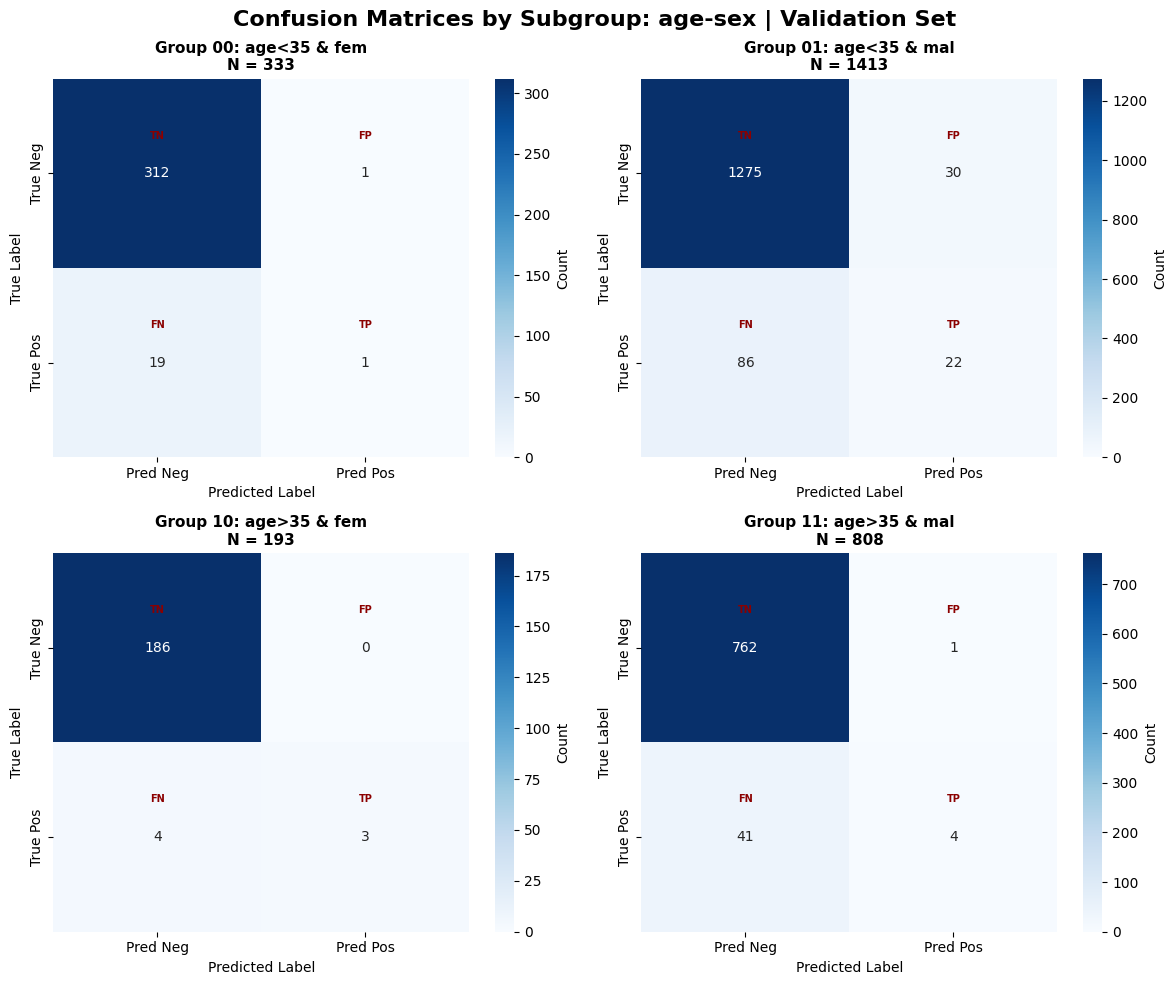

In [8]:
plot_confusion_matrix(cm_dict_val[sensible_attribute], '| Validation Set')

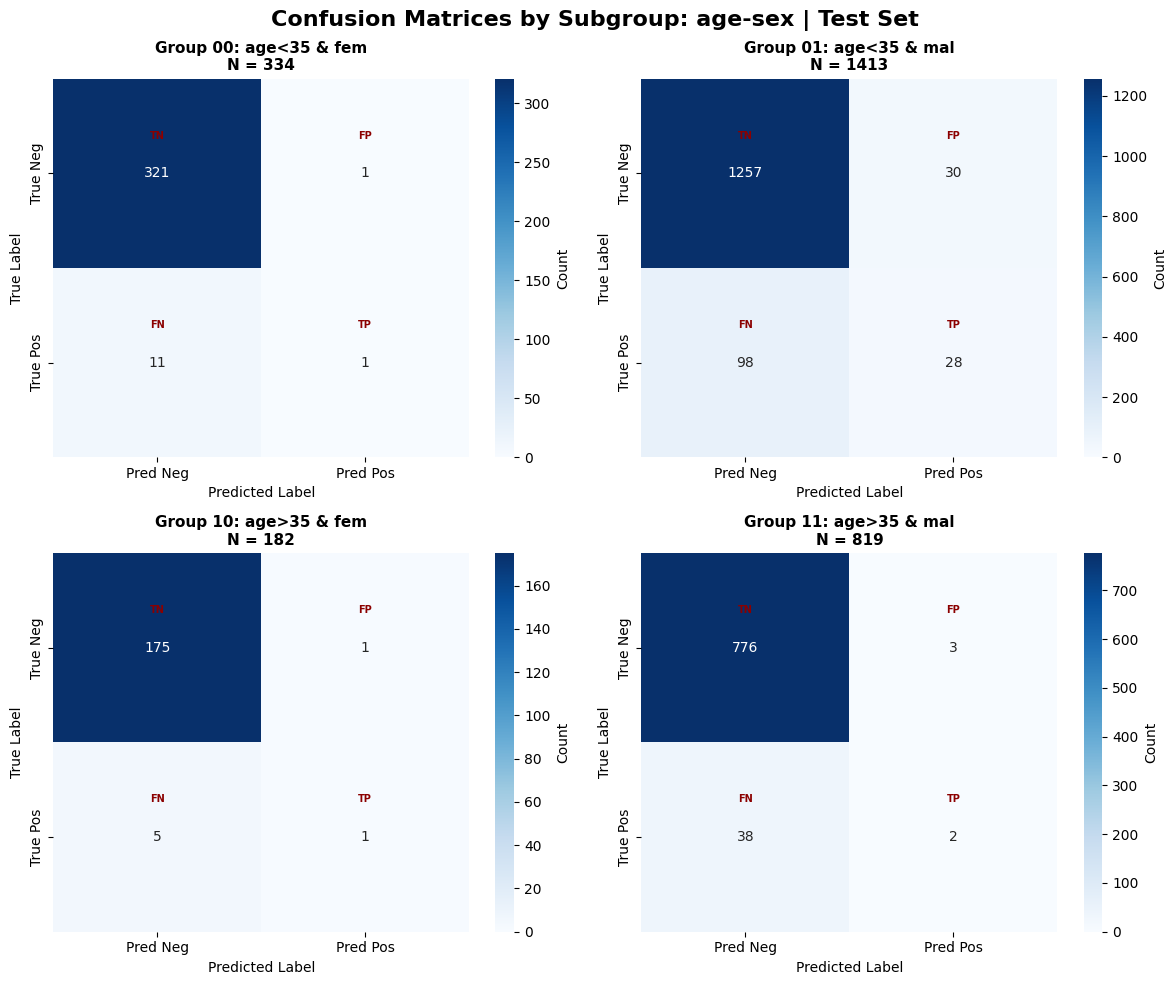

In [9]:
plot_confusion_matrix(cm_dict_test[sensible_attribute], '| Test Set')

# Compute Penalties: Validation and Test

Compute harmonic, geometric and arithmetic penalties, but only use harmonic for simplicity

In [10]:
# Compute BASELINE penalties on TEST set (Model 1 predictions)
penalties_ontest = {}
penalties_onval = {}
df_original = pd.read_csv(dataset_path)
individual_attributes = sensible_attribute.split('-')

for m in fair_metrics:
    # penalty_harm, penalty_geom, penalty_arith = compute_penalty_2(
    #     fairness_metrics_ontest_full, df_combined, 'sex', 'race', m
    # )
    penalties_ontest_harmonic, penalties_ontest_geometric, penalties_ontest_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test, df_original, individual_attributes[0], individual_attributes[1], m)

    penalties_ontest[m] = penalties_ontest_harmonic


    penalties_onval_harmonic, penalties_onval_geometric, penalties_onval_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_val, df_original, individual_attributes[0], individual_attributes[1], m)
    
    penalties_onval[m] = penalties_onval_harmonic
    
    # penalties_ontest[m] = {
    #     'harmonic': penalty_harm
    #     'geometric': penalty_geom,
    #     'arithmetic': penalty_arith
    # }

# Weights Functions

Three ways of calculating the weights, all **implemented** with the same function above (Model 2)

MAINLY FOCUSING ON NOTSIZED WEIGHTS.



### $w_i = 1 + \lambda * Penalty(g_i) $

This type of weight calculation has proven to be the most reliable and consistent, so we are mainly focusing on it during experiments.

In [11]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [12]:
def compute_weights_notsized(lambda_=5.0, m='FPN'):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized


In [13]:
# Keep a single standard weight for other parts of the notebook
weights_notsized = compute_weights_notsized(5.0)

Training samples: 12821, Unique weights per group: {'00': 2.6093750000000004, '01': 0.296140282131661, '10': 6.0, '11': 4.351370851370852}


### $w_i = 1 + \lambda * Penalty(g_i) * \frac{|g_i|}{|G_{max}|} $

In [14]:
df = prepare_dataframe_for_attribute(dataset_path, sensible_attribute)

In [15]:
def compute_weights_sized(lambda_=1.0, m='PPE'):

    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))

    # # Calculate average weight per group from validation set
    # df['weight'] = weights
    group_counts2 = train_df[sensible_attribute].value_counts().to_dict() # |g_i| number of attribute value combinations for subgroup "group_col"
    max_group_size = max(group_counts2.values()) # |G_max| subgroup with the highest number of attribute value combinations (dimension)

    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100) * (group_counts2.get(group, 1)/max_group_size))
        for group, penalty in penalties_onval[m].items()
    }


    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_sized = weights_for_training

    return weights_sized

In [16]:
weights_sized = compute_weights_sized(10.0)

Training samples: 12821, Unique weights per group: {'00': 1.2604229237919682, '01': 0.01, '10': 2.305816686251469, '11': 4.495036292204222}


---

In [17]:
def compute_fixed_weights(lambda_=5.0, m='FPN', fixed_weights=None):
    train_df = X_train[sensible_attribute].copy()
    weights_for_training = np.ones(len(train_df))
    # lambda_ = 10.0
    group_weights = {
        group: max(0.01, 1 + lambda_ * (penalty / 100))
        for group, penalty in penalties_onval[m].items()
    }

    weights_notsized = fixed_weights # in the form of a dictionary {'00': weight1, '01': weight2, ...}

    # Assign weights to training samples based on their group
    for i, (idx, row) in enumerate(train_df.iterrows()):
        group = row[sensible_attribute]
        if group in group_weights:
            weights_for_training[i] = group_weights[group]

    print(f"Training samples: {len(weights_for_training)}, Unique weights per group: {group_weights}")
    weights_notsized = weights_for_training

    return weights_notsized

# Model 2: Fairness metrics and penalty after reweighting

## Function

To compute penalties for Model 2:
- **Actual value**: Fairness metric for `sex-race` using Model 2's predictions
- **Predicted value**: Harmonic mean of `sex` and `race` metrics using Model 2's predictions

**Weights were computed on validation set, then propagated to the training set based on group membership.** 

**Now we fit the model on training set with these weights and evaluate on test set.**

In [18]:
def compute_penalties_after_reweighting(weights, fairness_metric):
    # Train Model 2 ONLY on the combined attribute (sensible_attribute) with weights
    import xgboost as xgb
    
    # Convert string combinations to numeric codes for XGBoost
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    # Train model with weights on combined attribute
    model_reweighed = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_reweighed.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    
    # Predict on test set
    y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)
    
    # Compute fairness metrics for ALL attributes (individual + combined)
    attributes = sensible_attribute.split('-') + [sensible_attribute]
    fairness_metrics_dict_test_reweighed = {}
    
    for attribute in attributes:
        df = prepare_dataframe_for_attribute(dataset_path, attribute)
        
        # Compute sensible_indexes_test FRESH for this specific attribute
        sensible_indexes_test_attr = df[attribute].loc[list(X_test[attribute].index)]
        
        # Compute FAIRNESS METRICS for each attribute on TEST set
        # Use the SAME predictions (from combined attribute) for all attributes
        fairness_metrics_dict_test_reweighed[attribute], group_counts_test_reweighed, cm_dict_test_reweighed = \
        get_fairness_metrics(df, attribute, sensible_indexes_test_attr, \
        y_pred_test_reweighed_combined, y_test[attribute], X_test[attribute], \
        fair_metrics, dataset_path, mapping, target_variable_labels=['0', '1'])

    individual_attributes = sensible_attribute.split('-')
    df_original = pd.read_csv(dataset_path)

    penalties_ontest_reweighed_harmonic, penalties_ontest_reweighed_geometric, penalties_ontest_reweighed_arithmetic = \
    compute_penalty_2(fairness_metrics_dict_test_reweighed, df_original, individual_attributes[0], individual_attributes[1], fairness_metric)

    return penalties_ontest_reweighed_harmonic

### Example

In [19]:
weights_notsized = compute_weights_notsized(5.0, 'FPN')
compute_penalties_after_reweighting(weights_notsized, 'FPN')

Training samples: 12821, Unique weights per group: {'00': 2.6093750000000004, '01': 0.296140282131661, '10': 6.0, '11': 4.351370851370852}
{np.int64(1): array([[950,   5],
       [ 44,   2]]), np.int64(0): array([[1608,    1],
       [ 131,    7]])}


{np.int64(1): array([[2062,    4],
       [ 159,    7]]), np.int64(0): array([[496,   2],
       [ 16,   2]])}
{'11': array([[776,   3],
       [ 39,   1]]), '01': array([[1286,    1],
       [ 120,    6]]), '10': array([[174,   2],
       [  5,   1]]), '00': array([[322,   0],
       [ 11,   1]])}


{'00': 100.0,
 '01': 28.615702479338832,
 '10': -168.57142857142858,
 '11': -80.53571428571426}

# Performance Comparison

In [20]:
def performance_after_reweighting(weights): 
    import xgboost as xgb
    
    # Convert string combinations to numeric codes for XGBoost
    X_train_numeric = X_train[sensible_attribute].copy()
    X_train_numeric[sensible_attribute] = X_train_numeric[sensible_attribute].astype('category').cat.codes
    
    X_test_numeric = X_test[sensible_attribute].copy()
    X_test_numeric[sensible_attribute] = X_test_numeric[sensible_attribute].astype('category').cat.codes
    
    # Train model with weights on combined attribute
    model_reweighed = xgb.XGBClassifier(random_state=1234, eval_metric='logloss')
    model_reweighed.fit(X_train_numeric, y_train[sensible_attribute], sample_weight=weights)
    
    # Predict on test set
    y_pred_test_reweighed_combined = model_reweighed.predict(X_test_numeric)

    perf_metrics = performance_metrics(y_test[sensible_attribute], y_pred_test_reweighed_combined)
    
    return perf_metrics


In [21]:
performance_metrics_test[sensible_attribute]

(0.47761194029850745,
 0.17391304347826086,
 0.9319505094614265,
 0.2549800796812749)

In [22]:
weights_notsized = compute_weights_notsized(5.0, 'FPN')
performance_metrics_after = performance_after_reweighting(weights_notsized)

Training samples: 12821, Unique weights per group: {'00': 2.6093750000000004, '01': 0.296140282131661, '10': 6.0, '11': 4.351370851370852}
Precision: 0.6, Recall: 0.04891304347826087, Accuracy: 0.9341339155749636, F1: 0.09045226130653267


Observation: performance remains stable (in some cases even better). For higher lambdas (>20), the performance starts to drop. 

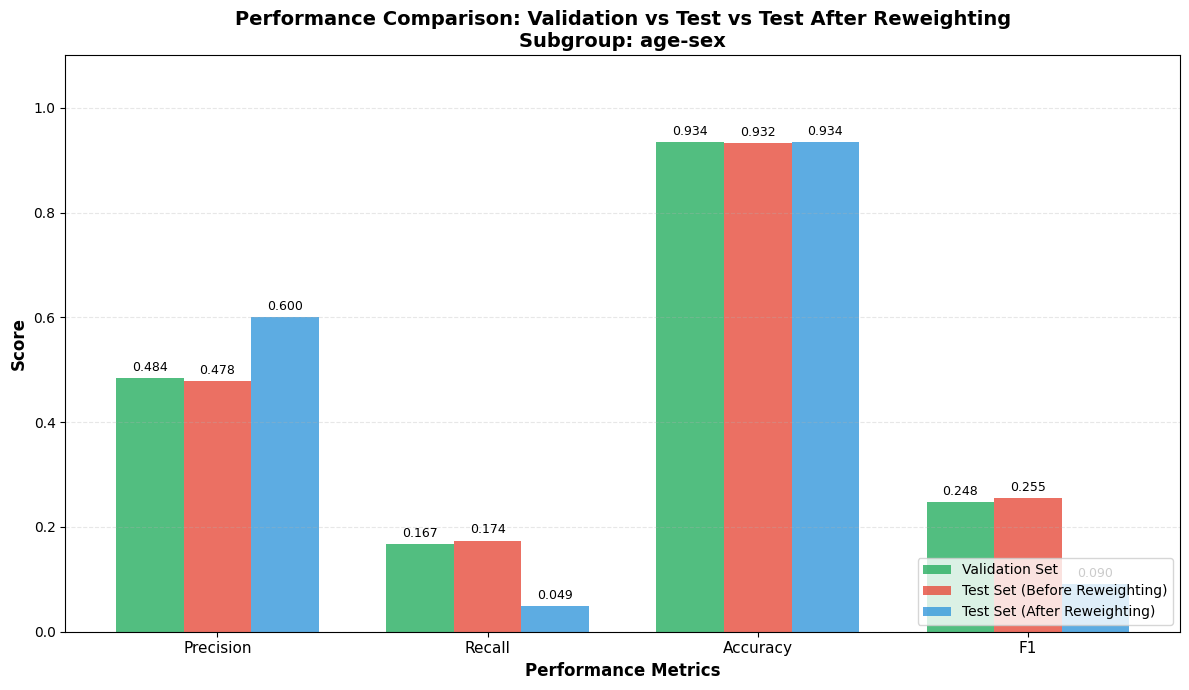


Performance Metrics Comparison:
Metric          Validation      Test (Before)   Test (After)    Δ (After-Before)
--------------------------------------------------------------------------------
Precision       0.4839          0.4776          0.6000          +0.1224
Recall          0.1667          0.1739          0.0489          -0.1250
Accuracy        0.9337          0.9320          0.9341          +0.0022
F1              0.2479          0.2550          0.0905          -0.1645


In [23]:
# Plot performance comparison
plot_performance_comparison(performance_metrics_val, performance_metrics_test, performance_metrics_after, sensible_attribute)

---

---

# Penalty After Reweighting Plots

### Utils

In [24]:
penalties_ontest_after_reweighting = {}
cm_dict_reweighted = {}

fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
for metric in fair_metrics:
    # print("FAIRNESS METRIC:", metric)
    weights_notsized = compute_weights_notsized(5.0, metric)
    penalties_ontest_after_reweighting[metric] = compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
    # print("\n")

Training samples: 12821, Unique weights per group: {'00': 2.6093750000000004, '01': 0.296140282131661, '10': 6.0, '11': 4.351370851370852}
{np.int64(1): array([[950,   5],
       [ 44,   2]]), np.int64(0): array([[1608,    1],
       [ 131,    7]])}


{np.int64(1): array([[2062,    4],
       [ 159,    7]]), np.int64(0): array([[496,   2],
       [ 16,   2]])}
{'11': array([[776,   3],
       [ 39,   1]]), '01': array([[1286,    1],
       [ 120,    6]]), '10': array([[174,   2],
       [  5,   1]]), '00': array([[322,   0],
       [ 11,   1]])}


Training samples: 12821, Unique weights per group: {'00': 1.6105231629392973, '01': 0.01, '10': 6.0, '11': 4.239951944080385}
{np.int64(1): array([[950,   5],
       [ 44,   2]]), np.int64(0): array([[1584,   25],
       [ 131,    7]])}


{np.int64(1): array([[2040,   26],
       [ 159,    7]]), np.int64(0): array([[494,   4],
       [ 16,   2]])}
{'11': array([[775,   4],
       [ 39,   1]]), '01': array([[1265,   22],
       [ 120,    6]]), '10': array([[175,   1],
       [  5,   1]]), '00': array([[319,   3],
       [ 11,   1]])}


Training samples: 12821, Unique weights per group: {'00': 4.246746746746746, '01': 0.12993188251946064, '10': 0.01, '11': 3.914555615717822}
{np.int64(1): array([[951,   4],
       [ 45,   1]]), np.int64(0): array([[1603,    6],
       [ 130,    8]])}


...

{np.int64(1): array([[2060,    6],
       [ 151,   15]]), np.int64(0): array([[494,   4],
       [ 17,   1]])}
{'11': array([[778,   1],
       [ 38,   2]]), '01': array([[1282,    5],
       [ 113,   13]]), '10': array([[175,   1],
       [  5,   1]]), '00': array([[319,   3],
       [ 12,   0]])}


Training samples: 12821, Unique weights per group: {'00': 0.09900354900354924, '01': 0.5732785725058872, '10': 3.58243052284503, '11': 0.8046050762863172}
{np.int64(1): array([[953,   2],
       [ 44,   2]]), np.int64(0): array([[1606,    3],
       [ 129,    9]])}
{np.int64(1): array([[2063,    3],
       [ 156,   10]]), np.int64(0): array([[496,   2],
       [ 17,   1]])}


{'11': array([[778,   1],
       [ 39,   1]]), '01': array([[1285,    2],
       [ 117,    9]]), '10': array([[175,   1],
       [  5,   1]]), '00': array([[321,   1],
       [ 12,   0]])}


Training samples: 12821, Unique weights per group: {'00': 1.6414226726726735, '01': 0.01, '10': 6.0, '11': 4.243183693369337}
{np.int64(1): array([[950,   5],
       [ 44,   2]]), np.int64(0): array([[1588,   21],
       [ 132,    6]])}


{np.int64(1): array([[2041,   25],
       [ 160,    6]]), np.int64(0): array([[497,   1],
       [ 16,   2]])}
{'11': array([[775,   4],
       [ 39,   1]]), '01': array([[1266,   21],
       [ 121,    5]]), '10': array([[175,   1],
       [  5,   1]]), '00': array([[322,   0],
       [ 11,   1]])}


## Penalty before and after reweighting

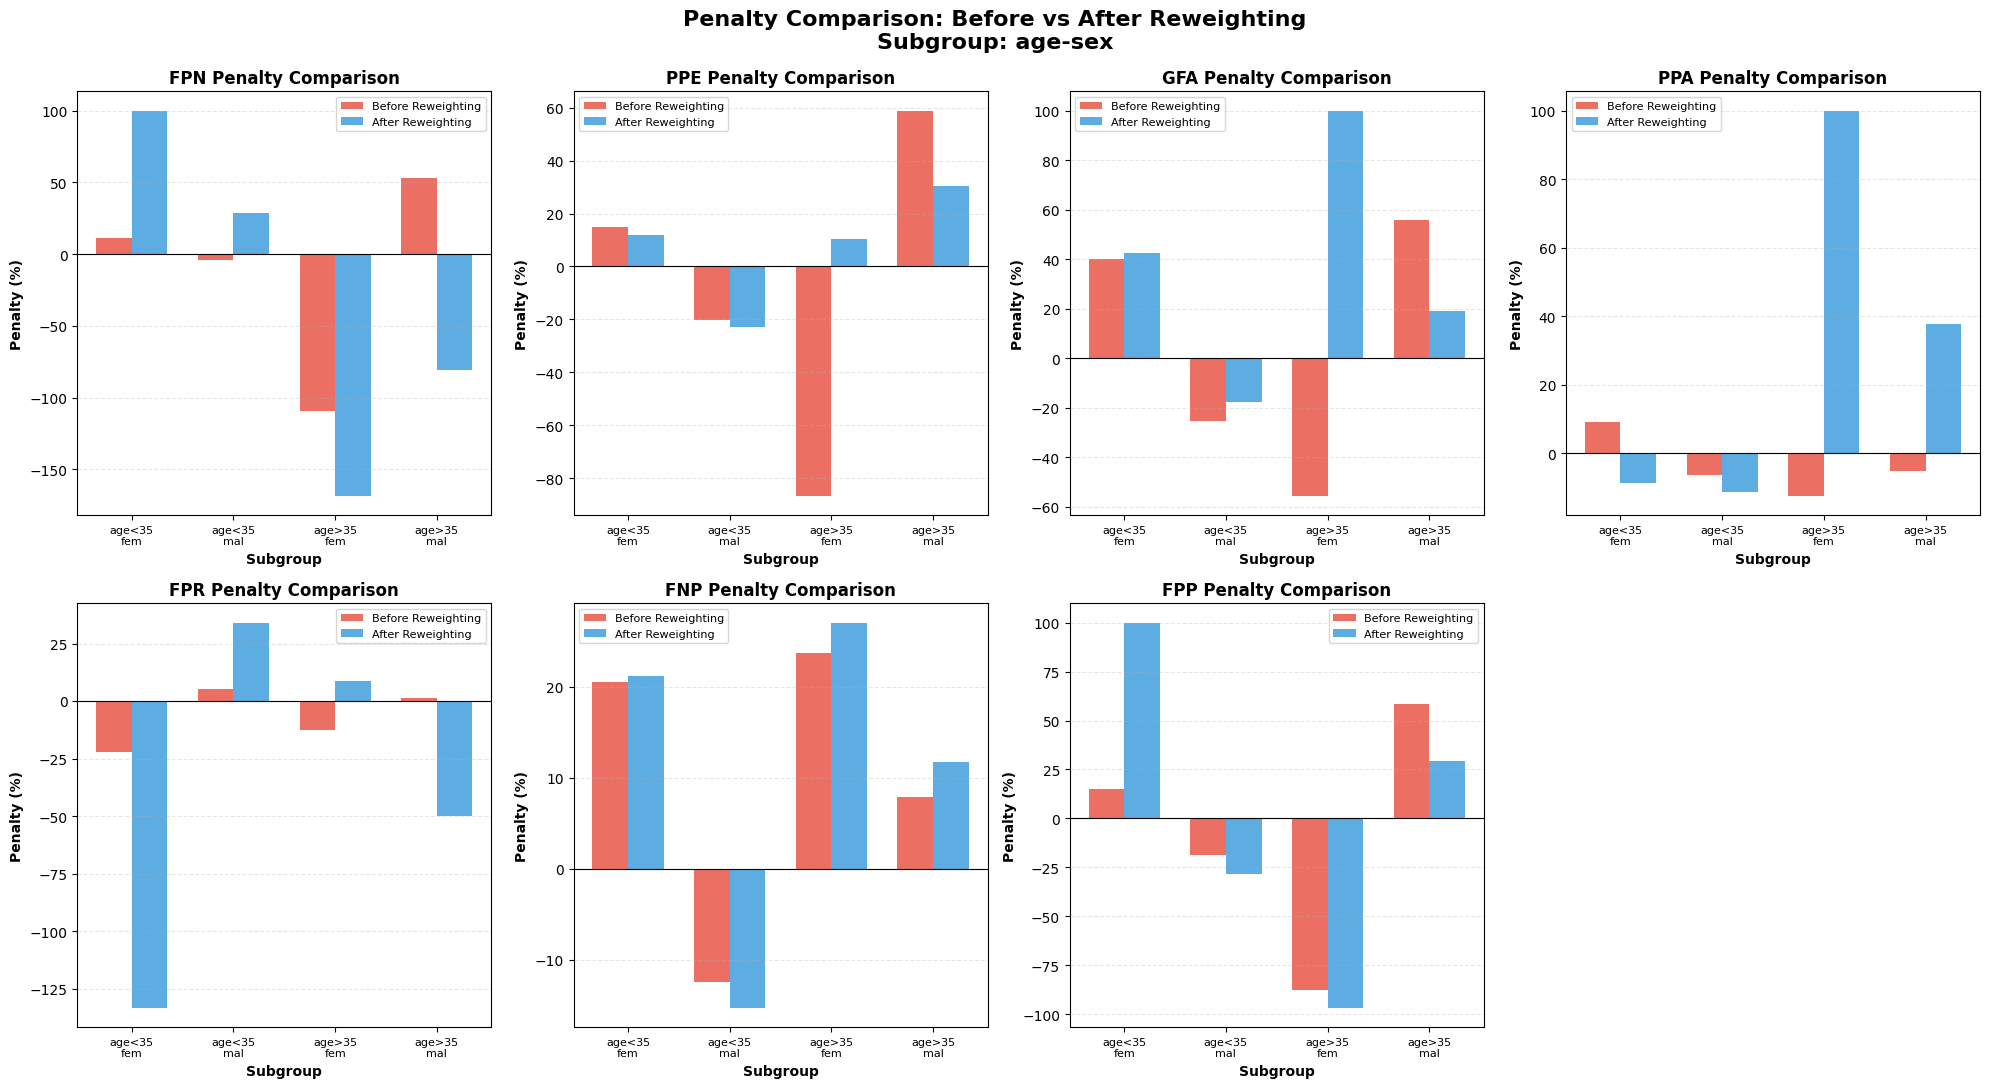

In [25]:
import matplotlib.pyplot as plt
import numpy as np

def plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    """
    Generalized version that works with any subgroup combination.
    
    Args:
        fair_metrics: List of fairness metrics to plot
        penalties_ontest: Dictionary of penalties before reweighting {metric: {subgroup: penalty}}
        penalties_ontest_after_reweighting: Dictionary of penalties after reweighting
        sensible_attribute: String like 'age-edu', 'sex-race', etc.
        mapping: Dictionary mapping attribute codes to labels
    """
    # Extract subgroups (assuming all metrics have the same subgroups)
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())
    
    # Parse the sensible_attribute to get individual attributes
    individual_attrs = sensible_attribute.split('-')
    
    # Set up the plot
    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    axes = axes.flatten()

    # Create a bar plot for each metric
    for idx, metric in enumerate(fair_metrics):
        ax = axes[idx]
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=10, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=10, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=12, fontweight='bold')
        ax.set_xticks(x)
        
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
        
        ax.set_xticklabels(decoded_labels, fontsize=8)
        ax.legend(fontsize=8)
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)

    # Remove extra subplots if any
    for idx in range(len(fair_metrics), len(axes)):
        fig.delaxes(axes[idx])

    plt.tight_layout()
    plt.suptitle(f'Penalty Comparison: Before vs After Reweighting\nSubgroup: {sensible_attribute}', 
                fontsize=16, fontweight='bold', y=1.03)
    plt.show()

# Use the generalized function
fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
                                        sensible_attribute, mapping)

In [26]:
# lambdas = [0.5, 1.0, 2.0, 5.0, 10.0]

# for l in lambdas:
#     penalties_ontest_after_reweighting = {}

#     fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'OAE', 'FPR', 'FPA', 'EOP', 'FNP', 'FPP']
#     for metric in fair_metrics:
#         # print("FAIRNESS METRIC:", metric)
#         weights_notsized = compute_weights_notsized(l, metric)
#         penalties_ontest_after_reweighting[metric]= compute_penalties_after_reweighting(weights_notsized, metric) # Get only harmonic penalty
#         # print("\n")

#     fair_metrics=['FPN', 'PPE', 'GFA', 'PPA', 'FPR', 'FNP', 'FPP']
#     plot_penalty_comparison_all_generalized(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, 
#                                             sensible_attribute, mapping)

In [27]:
# Individual plots for each metric (larger view for detailed inspection)
def plot_penalty_comparison_all_individual(fair_metrics, penalties_ontest, penalties_ontest_after_reweighting, sensible_attribute, mapping):
    subgroups = list(penalties_ontest[fair_metrics[0]].keys())

    for metric in fair_metrics:
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        
        # Extract penalties before and after for this metric
        penalties_before = [penalties_ontest[metric].get(group, 0) for group in subgroups]
        penalties_after = [penalties_ontest_after_reweighting[metric].get(group, 0) for group in subgroups]
        
        # Set up bar positions
        x = np.arange(len(subgroups))
        width = 0.35
        
        # Create bars
        bars1 = ax.bar(x - width/2, penalties_before, width, label='Before Reweighting', alpha=0.8, color='#e74c3c')
        bars2 = ax.bar(x + width/2, penalties_after, width, label='After Reweighting', alpha=0.8, color='#3498db')
        
        # Add value labels on bars
        for bar in bars1:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        for bar in bars2:
            height = bar.get_height()
            ax.annotate(f'{height:.1f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),  # 3 points vertical offset
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=9)
        
        individual_attrs = sensible_attribute.split('-')
        # Decode subgroup labels dynamically based on sensible_attribute
        decoded_labels = []
        for group in subgroups:
            # Decode each character in the group code using corresponding attribute
            decoded_parts = []
            for i, attr in enumerate(individual_attrs):
                attr_code = int(group[i])
                attr_label = mapping[attr][attr_code]
                decoded_parts.append(attr_label)
            
            # Join with newline for multi-line labels
            decoded_labels.append('\n'.join(decoded_parts))
       
        
        # Customize plot
        ax.set_xlabel('Subgroup', fontsize=12, fontweight='bold')
        ax.set_ylabel('Penalty (%)', fontsize=12, fontweight='bold')
        ax.set_title(f'{metric} Penalty Comparison', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(decoded_labels, fontsize=10)
        ax.legend(fontsize=11, loc='best')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.8)
        
        plt.tight_layout()
        plt.show()
        print(f"\n{metric} - Penalty Changes:")
        for i, group in enumerate(subgroups):
            before = penalties_before[i]
            after = penalties_after[i]
            change = after - before
            print(f"  {decoded_labels[i].replace(chr(10), '-')}: {before:.2f} → {after:.2f} (Δ = {change:+.2f})")
        print("-" * 60)

---

# Threshold Optimization

**Problem:** With the default threshold of 0.5, recall and F1 are very low due to severe class imbalance.

**Solution:** Experiment with lower thresholds to balance precision and recall.

In [28]:
def find_optimal_threshold(model, X_val, y_val, thresholds=np.arange(0.1, 0.6, 0.05)):
    """
    Find the best threshold by evaluating F1 score across different threshold values.
    
    Args:
        model: Trained XGBoost model
        X_val: Validation features (will be converted to numeric if needed)
        y_val: Validation labels
        thresholds: Array of thresholds to test
    
    Returns:
        best_threshold, results_df
    """
    from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
    
    # Convert categorical columns to numeric codes for XGBoost
    X_val_numeric = X_val.copy()
    if sensible_attribute in X_val_numeric.columns:
        X_val_numeric[sensible_attribute] = X_val_numeric[sensible_attribute].astype('category').cat.codes
    
    results = []
    y_proba = model.predict_proba(X_val_numeric)[:, 1]
    
    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)
        
        results.append({
            'Threshold': threshold,
            'Precision': precision_score(y_val, y_pred),
            'Recall': recall_score(y_val, y_pred),
            'F1': f1_score(y_val, y_pred),
            'Accuracy': accuracy_score(y_val, y_pred)
        })
    
    results_df = pd.DataFrame(results)
    best_idx = results_df['F1'].idxmax()
    best_threshold = results_df.loc[best_idx, 'Threshold']
    
    print("Threshold Optimization Results:")
    print("=" * 80)
    print(results_df.to_string(index=False))
    print("=" * 80)
    print(f"\n✓ Best Threshold: {best_threshold:.2f} (F1 = {results_df.loc[best_idx, 'F1']:.4f})")
    
    return best_threshold, results_df

# Example usage (commented out - uncomment to use):
best_threshold, threshold_results = find_optimal_threshold(
    model_baseline_test[sensible_attribute], 
    X_test[sensible_attribute], 
    y_test[sensible_attribute]
)

Threshold Optimization Results:
 Threshold  Precision   Recall       F1  Accuracy
      0.10   0.165493 0.510870 0.250000  0.794760
      0.15   0.224265 0.331522 0.267544  0.878457
      0.20   0.312057 0.239130 0.270769  0.913755
      0.25   0.377551 0.201087 0.262411  0.924309
      0.30   0.477612 0.173913 0.254980  0.931951
      0.35   0.600000 0.114130 0.191781  0.935590
      0.40   0.666667 0.097826 0.170616  0.936317
      0.45   0.652174 0.081522 0.144928  0.935590
      0.50   0.684211 0.070652 0.128079  0.935590
      0.55   0.750000 0.048913 0.091837  0.935226

✓ Best Threshold: 0.20 (F1 = 0.2708)


---